# GitHub Repository Recommender System

## Overview
This project builds a recommender system for GitHub repositories. 
Given a user's public repositories, the system suggests other repositories that are similar in terms of description

### purpose of this notebook

- Collect data from GitHub API

- Preprocess repository metadata

- Train a clustering model (K-Means)

- Recommend repositories based on clusters

## 1. Imports

In [1]:
import requests
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Function for collecting the repos from github API (1000 repos)

In [2]:

GITHUB_API = "https://api.github.com/search/repositories"

def fetch_repos(languages, pages_per_lang=2):
    """
    Fetch GitHub repos by language.
    
    languages: list of languages to fetch (["Python", "JavaScript"])
    pages_per_lang: number of pages to fetch per language (100 repos per page)
    """
    all_repos = []

    headers = {"Accept": "application/vnd.github.mercy-preview+json"}  # for topics

    for lang in languages:
        print(f"Fetching language: {lang}")
        for page in range(1, pages_per_lang + 1):
            params = {
                "q": f"stars:>1000 language:{lang}",
                "sort": "stars",
                "order": "desc",
                "per_page": 100,
                "page": page
            }

            response = requests.get(GITHUB_API, params=params, headers=headers)
            
            if response.status_code != 200:
                print(f"Error fetching {lang} page {page}: {response.status_code}")
                break

            data = response.json()

            if "items" not in data:
                break

            for repo in data["items"]:
                topics = " ".join(repo.get("topics", []))
                all_repos.append({
                    "name": repo["name"],
                    "description": repo["description"] or "",
                    "language": repo["language"] or "",
                    "topics": topics,
                    "stars": repo["stargazers_count"],
                    "url": repo["html_url"]
                })

    df = pd.DataFrame(all_repos)
    df = df.drop_duplicates(subset="url").reset_index(drop=True)
    return df



In [3]:
# Example usage
languages = ["Python", "JavaScript", "Java", "Go", "Rust"]
df = fetch_repos(languages, pages_per_lang=2)

print(f"Fetched {df.shape[0]} repositories")
df.head()

Fetching language: Python
Fetching language: JavaScript
Fetching language: Java
Fetching language: Go
Fetching language: Rust
Error fetching Rust page 2: 403
Fetched 900 repositories


,name,description,language,topics,stars,url
0,public-apis,A collective list of free APIs,Python,api apis dataset development free list lists o...,412883,https://github.com/public-apis/public-apis
1,free-programming-books,:books: Freely available programming books,Python,books education hacktoberfest list resource,384357,https://github.com/EbookFoundation/free-progra...
2,system-design-primer,Learn how to design large-scale systems. Prep ...,Python,design design-patterns design-system developme...,339670,https://github.com/donnemartin/system-design-p...
3,awesome-python,An opinionated list of awesome Python framewor...,Python,awesome collections python python-framework py...,288279,https://github.com/vinta/awesome-python
4,Python,All Algorithms implemented in Python,Python,algorithm algorithm-competitions algorithms-im...,218923,https://github.com/TheAlgorithms/Python


In [4]:
df.shape[0]

900

## Creating a new column with all the text to be used for training

In [6]:
def build_text(row):
    return f"{row['description']} {row['language']} {row['topics']}"

df["text"] = df.apply(build_text, axis=1)
df.head()

,name,description,language,topics,stars,url,text
0,public-apis,A collective list of free APIs,Python,api apis dataset development free list lists o...,412883,https://github.com/public-apis/public-apis,A collective list of free APIs Python api apis...
1,free-programming-books,:books: Freely available programming books,Python,books education hacktoberfest list resource,384357,https://github.com/EbookFoundation/free-progra...,:books: Freely available programming books Pyt...
2,system-design-primer,Learn how to design large-scale systems. Prep ...,Python,design design-patterns design-system developme...,339670,https://github.com/donnemartin/system-design-p...,Learn how to design large-scale systems. Prep ...
3,awesome-python,An opinionated list of awesome Python framewor...,Python,awesome collections python python-framework py...,288279,https://github.com/vinta/awesome-python,An opinionated list of awesome Python framewor...
4,Python,All Algorithms implemented in Python,Python,algorithm algorithm-competitions algorithms-im...,218923,https://github.com/TheAlgorithms/Python,All Algorithms implemented in Python Python al...


In [7]:
df.tail()

,name,description,language,topics,stars,url,text
895,neon,Neon: Serverless Postgres. We separated storag...,Rust,database postgres postgresql rust serverless,21265,https://github.com/neondatabase/neon,Neon: Serverless Postgres. We separated storag...
896,sonic,"🦔 Fast, lightweight & schema-less search backe...",Rust,backend database graph index infrastructure ru...,21164,https://github.com/valeriansaliou/sonic,"🦔 Fast, lightweight & schema-less search backe..."
897,flow,Everything you need to move your project faster,Rust,rust,21154,https://github.com/nikivdev/flow,Everything you need to move your project faste...
898,eza,A modern alternative to ls,Rust,color command-line files hacktoberfest icons l...,20702,https://github.com/eza-community/eza,A modern alternative to ls Rust color command-...
899,wasmer,"🚀 Fast, secure, lightweight containers based o...",Rust,emscripten linux macos rust wasi wasix wasm wa...,20518,https://github.com/wasmerio/wasmer,"🚀 Fast, secure, lightweight containers based o..."


## Since Computers do not understand text, we convert the text to numeric vectors
### Feature engineering

In [8]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df["text"])


## Model training
- Clustering using K-Means:
    - Group repositories into clusters based on content similarity
    - `n_clusters` = 10 (can be tuned)
- Save models using `pickle` for later use in recommendations.

In [9]:
kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [10]:
df["cluster"] = kmeans.labels_

In [11]:
df.head()

,name,description,language,topics,stars,url,text,cluster
0,public-apis,A collective list of free APIs,Python,api apis dataset development free list lists o...,412883,https://github.com/public-apis/public-apis,A collective list of free APIs Python api apis...,1
1,free-programming-books,:books: Freely available programming books,Python,books education hacktoberfest list resource,384357,https://github.com/EbookFoundation/free-progra...,:books: Freely available programming books Pyt...,2
2,system-design-primer,Learn how to design large-scale systems. Prep ...,Python,design design-patterns design-system developme...,339670,https://github.com/donnemartin/system-design-p...,Learn how to design large-scale systems. Prep ...,6
3,awesome-python,An opinionated list of awesome Python framewor...,Python,awesome collections python python-framework py...,288279,https://github.com/vinta/awesome-python,An opinionated list of awesome Python framewor...,2
4,Python,All Algorithms implemented in Python,Python,algorithm algorithm-competitions algorithms-im...,218923,https://github.com/TheAlgorithms/Python,All Algorithms implemented in Python Python al...,2


## Visualizing the clusters

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X.toarray())

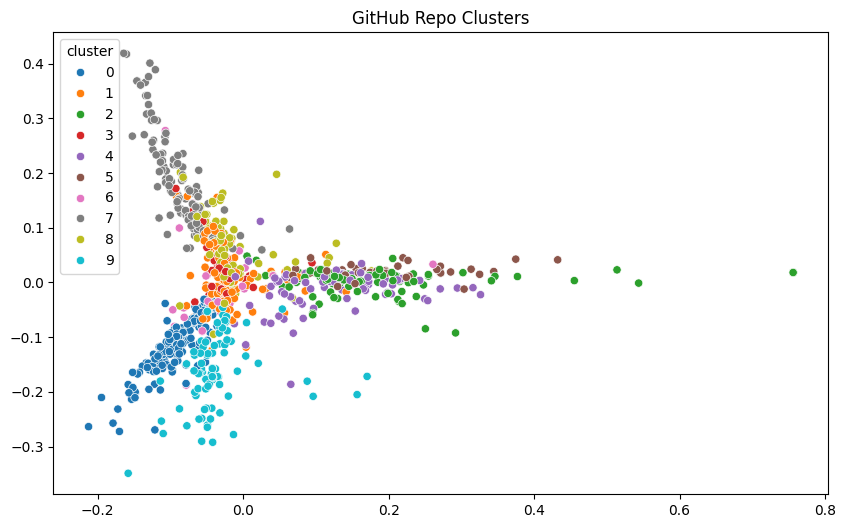

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_reduced[:,0], y=X_reduced[:,1], hue=df["cluster"], palette="tab10")
plt.title("GitHub Repo Clusters")
plt.show()

In [14]:

k = 10

df["cluster"] = kmeans.labels_

for i in range(k):
    print(f"\nCluster {i}")
    display(df[df["cluster"] == i][["name", "language", "stars"]].head(5))


Cluster 0


,name,language,stars
200,react,JavaScript,244110
201,javascript-algorithms,JavaScript,195787
202,javascript,JavaScript,148122
203,next.js,JavaScript,138422
205,node,JavaScript,116368



Cluster 1


,name,language,stars
0,public-apis,Python,412883
19,fastapi,Python,96438
30,spec-kit,Python,79137
33,PayloadsAllTheThings,Python,76242
49,localstack,Python,64716



Cluster 2


,name,language,stars
1,free-programming-books,Python,384357
3,awesome-python,Python,288279
4,Python,Python,218923
8,yt-dlp,Python,152357
9,HelloGitHub,Python,146898



Cluster 3


,name,language,stars
27,devops-exercises,Python,81608
101,copyparty,Python,43643
102,sentry,Python,43415
197,changedetection.io,Python,30732
215,uptime-kuma,JavaScript,84309



Cluster 4


,name,language,stars
5,AutoGPT,Python,182650
6,stable-diffusion-webui,Python,161920
10,langflow,Python,145982
12,langchain,Python,130458
13,open-webui,Python,128091



Cluster 5


,name,language,stars
7,transformers,Python,158187
18,pytorch,Python,98465
32,d2l-zh,Python,76372
39,awesome-machine-learning,Python,72044
45,annotated_deep_learning_paper_implementations,Python,66073



Cluster 6


,name,language,stars
2,system-design-primer,Python,339670
90,big-list-of-naughty-strings,Python,47611
103,python-patterns,Python,42800
204,30-seconds-of-code,JavaScript,127168
209,awesome-mac,JavaScript,100588



Cluster 7


,name,language,stars
400,JavaGuide,Java,154375
401,hello-algo,Java,123602
402,GitHub-Chinese-Top-Charts,Java,107009
404,mall,Java,83204
405,spring-boot,Java,80314



Cluster 8


,name,language,stars
28,Deep-Live-Cam,Python,80224
54,pathway,Python,61593
98,airflow,Python,44725
139,interview_internal_reference,Python,37208
143,sqlmap,Python,36882



Cluster 9


,name,language,stars
800,rust,Rust,111405
801,rustdesk,Rust,109744
802,deno,Rust,106441
803,tauri,Rust,104435
804,uv,Rust,81651


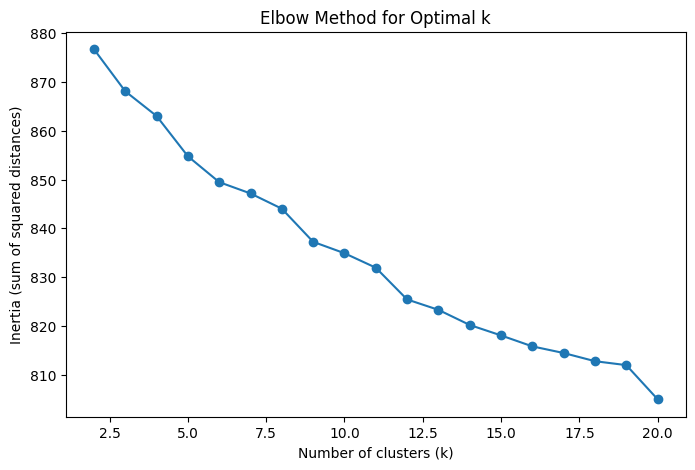

In [15]:
inertia = []

# Trying k from 2 to 20 
K_range = range(2, 21)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.title("Elbow Method for Optimal k")
plt.show()

### Insights
Although the model was trained with k=10 initially, I verified this choice using the Elbow Method. Inertia decreased sharply until k=10, supporting that this is a reasonable number of clusters for the dataset.

## Recommendations
- Transform a user's repositories using the saved TF-IDF vectorizer **(vectorizer.pkl)**
- Predict clusters using the saved K-Means model **(kmeans.pkl)**
- Recommend top repositories from the same clusters **(repos.pkl)**

In [16]:
import pickle

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("repos.pkl", "wb") as f:
    pickle.dump(df.to_dict(orient="records"), f)

## Future Improvements
- Incorporate GitHub stars and forks for ranking recommendations
- Use embeddings (BERT / SentenceTransformers) instead of TF-IDF for better semantic similarity
- Include a user interface to input a GitHub username and display recommendations